# Trading Desk Analysis
### FINM3422 - Assessment 3 | Risk & Derivatives Platform

---

__Purpose:__ This notebook is the Head Desk dashboard for the risk and derivatives platform built across `src/`. It integrates the four core modules (yield curve, derivative pricing, portfolio aggregation, risk analytics) into a single end-to-end workflow that:

1. Loads market data (RBA F17 yield curve, ASX equity prices via yfinance)
2. Constructs a focused portfolio demonstrating three distinct uses of options (hedging, income, speculation), one per underlying mechanism.
3. Reports portfolio value, dollar-delta exposures, and per-position Greeks
4. Cross-validates pricing methods (Black-Scholes, Binomial CRR, Monte Carlo) on a portfolio position.
5. Computes downside risk via three independent VaR methods, Expected Shortfall, and Maximum Drawdown
6. Stresses the portfolio under equity, vol, parallel rate, and non-parallel rate scenarios
7. Discusses limitations and next steps

The audience is a desk head or risk manager: they need to understand what the portfolio holds, what it is exposed to, and what could go wrong, without reading source code.

---

## Portfolio Design

Rather than a single overlay applied across many underlyings, we construct three positions, each demonstrating a distinct use of options per Lecture 11 slide 20 (Hedging, Speculation, Portfolio Construction):

| Underlying | Sector | Strategy | Use case |
|---|---|---|---|
| CBA | Banking | Long equity + protective put | Hedging |
| BHP | Materials | Long equity + short covered call | Income |
| CSL | Healthcare | Long equity + long ATM straddle | Speculation on volatility |

This structure lets the desk head see three distinct risk profiles in one portfolio, each defensible on its own economic terms.

## Data Sources

| Source | Provides | Update frequency |
|---|---|---|
| RBA F17 (Zero-Coupon Interest Rates, Analytical Series) | Risk-free yield curve | Daily (cached locally) |
| Yahoo Finance via `yfinance` | Equity spot, volatility, dividend yields, historical returns | On-demand (cached to CSV) |

## Module Map

| Module | Role |
|---|---|
| `src/yield_data_loader.py` | RBA F17 ingestion and caching |
| `src/yieldcurve.py` | Zero-rate construction, interpolation, discount factors |
| `src/market_data_loader.py` | Equity price, vol, and dividend data |
| `src/derivative_test.py` | BS, binomial CRR, MC pricers (European and American) |
| `src/portfolio_test.py` | Portfolio container, position aggregation, OOP risk methods |
| `src/risk.py` | Standalone VaR, ES, MDD, Monte Carlo risk functions |

In [1]:
# Environment and imports.
import sys, os
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from IPython.display import display

# Add the project root to Python's path so src/ modules can be imported.
sys.path.append(os.path.abspath('..'))

from src.yield_data_loader import load_yield_curve_data, get_latest_yields
from src.yieldcurve import YieldCurve
from src.market_data_loader import load_equity_data, get_equity_summary, default_stocks
from src.derivative_test import (
    EuropeanCall, EuropeanPut,
    BinomialEuropeanCall, BinomialEuropeanPut,
    AmericanCall, AmericanPut,
)
from src.portfolio_test import Portfolio, EquityPosition
from src import risk

# Display floats to 4 decimal places.
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility: fix MC seed throughout.
SEED = 42

# Print versions for environment documentation.
print()
print(f"Python    : {sys.version.split()[0]}")
print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"yfinance  : {yf.__version__}") 


Python    : 3.14.4
numpy     : 2.4.5
pandas    : 3.0.3
matplotlib: 3.10.9
yfinance  : 1.4.0


## 3.0 Yield Curve Construction

The yield curve is the platform's discounting infrastructure. It supplies the maturity-matched risk-free rate `r(T)` used in every option pricing call.

In [2]:
# Construct the yield curve from the most recent RBA F17 data.
yield_curve = YieldCurve.from_rba(interpolation="linear", compounding="continuous")

# Confirm rates at key option maturities.
print("\nRisk-free rates at key option maturities (from RBA F17):")
for T, label in [(0.25, "3 months"), (0.5, "6 months"), (1.0, "1 year"), (2.0, "2 years")]:
    r = yield_curve.get_zero_rate(T)
    d = yield_curve.get_discount_factor(T)
    print(f"  {label:<12} | r = {r*100:.4f}% | D(T) = {d:.6f}")

[data_loader] Loaded from cache: /Users/jordanwesterberg/FINM3422 A3 Derivatives Pricing/FINM3422_A3_T7_G1_DP/src/../data/F17_DATA_CLEAN.csv
 [YieldCurve] Built from RBA F17 data as of 30-04-2026.
 Maturtites: 41 points (0yr to 10yr in 0.25yr increments.)
 Compounding: continuous
 Interpolation: linear

Risk-free rates at key option maturities (from RBA F17):
  3 months     | r = 4.3000% | D(T) = 0.989308
  6 months     | r = 4.4600% | D(T) = 0.977947
  1 year       | r = 4.6300% | D(T) = 0.954755
  2 years      | r = 4.6900% | D(T) = 0.910465


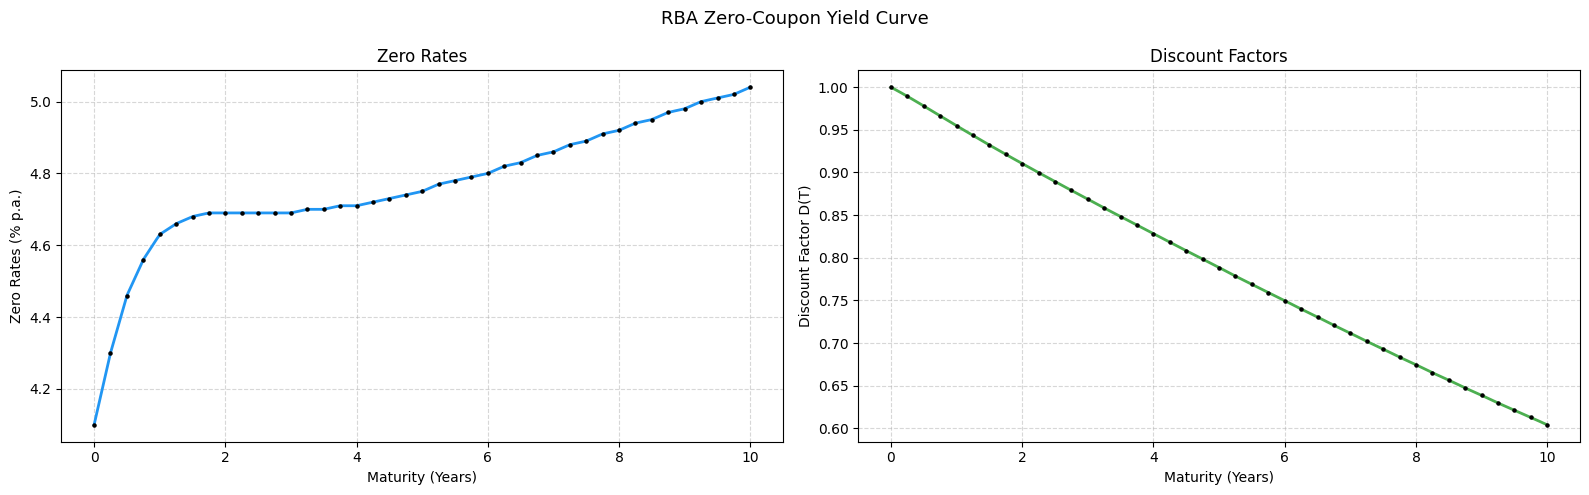

In [3]:
yield_curve.plot()

## 4.0 Equity Data

We focus on three ASX-listed equities, one per option use case. The `market_data_loader` module handles spot prices, annualised volatility, and dividend yields, caching results to CSV for reproducibility. Historical log-return series are pulled separately for VaR and for constructing the empirical correlation matrix used in multi-asset Monte Carlo.

> **Note on reproducibility**: equity data is cached at `data/equity_data.csv`. To refresh from yfinance, call `load_equity_data(use_cache=False)` or delete the cache file.

In [4]:
# Select the 3 tickers for our focused portfolio.
selected_tickers = ["CBA", "BHP", "CSL"]
stocks = {k: dict(default_stocks[k]) for k in selected_tickers}

# Load market data for the selected stocks.
stocks = load_equity_data(stocks=stocks, use_cache=True)

# Pull historical log returns separately for VaR and correlation matrix.
for name, info in stocks.items():
    data = yf.download(info["ticker"], period="2y", auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        close = data[("Close", info["ticker"])]
    else:
        close = data["Close"]
    info["log_returns"] = np.log(close / close.shift(1)).dropna()

print("\nEquity universe (2-year historical volatility, current dividend yields):")
display(get_equity_summary(stocks))

[market_data] Loaded from cache: /Users/jordanwesterberg/FINM3422 A3 Derivatives Pricing/FINM3422_A3_T7_G1_DP/src/../data/equity_data.csv
[market_data] Loaded return series from cache: /Users/jordanwesterberg/FINM3422 A3 Derivatives Pricing/FINM3422_A3_T7_G1_DP/src/../data/equity_returns.csv

Equity universe (2-year historical volatility, current dividend yields):


,Stock,Sector,Spot Price ($),Volatility (% p.a.),Div Yield (%) [yfinance]
,CBA,Banking,164.2900,23.3700,2.9900
,BHP,Materials,60.3500,24.9500,3.2800
,CSL,Healthcare,98.4000,30.9100,4.2700


### Summary of capital deployed

| Strategy | Equity capital | Net option premium | Net dollar-delta exposure |
|---|---|---|---|
| CBA hedging | $99,402 | -$3,863 (paid) | ~$67,000 (equity less put delta) |
| BHP income | $101,575 | +$5,212 (received) | ~$58,000 (equity less short-call delta) |
| CSL speculation | $99,760 | -$8,479 (paid) | ~$104,000 (equity plus small straddle delta) |
| **Total equity** | **$300,737** | **-$7,130** | **~$229,000** |

The three strategies receive approximately equal dollar allocation in equity ($100k each). After the option overlays, however, the **effective dollar-delta exposure** differs across strategies:

- CBA's protective put reduces CBA's directional exposure by about $32k (from $99k equity to $67k effective)
- BHP's short call reduces BHP's directional exposure by about $43k (from $102k equity to $58k effective)
- CSL's long straddle is approximately delta-neutral at ATM, so CSL's exposure stays close to its $100k equity

This is the central point of the platform: the head desk sees three strategies that look equally-weighted by capital but have very different effective risk exposures. Dollar-delta makes this visible.

> **TODO (team)**: position sizes assume a $100k-per-strategy allocation. If the equity-research workstream recommends different conviction weightings, the sizing rules above can be re-applied with new dollar targets.

In [5]:
# Build the portfolio: three distinct strategies, one per ticker.
# Position sizes are derived from explicit sizing rules (see markdown above).

# === Equity sizing: target ~$100k per strategy (equal-dollar allocation) ===
CBA_SHARES = 600    # 600 × $165.67 = $99,402
BHP_SHARES = 1700   # 1700 × $59.75 = $101,575
CSL_SHARES = 1000   # 1000 × $99.76 = $99,760

# === Option contract counts (each contract = 100 shares per ASX convention) ===
CBA_PUT_CONTRACTS      = 6    # 100% hedge ratio: 6 contracts × 100 shares = 600 shares-equivalent
BHP_CALL_CONTRACTS     = 17   # 100% cover ratio: 17 contracts × 100 shares = 1,700 shares-equivalent
CSL_STRADDLE_CONTRACTS = 5    # ~$8,500 premium budget (caps max straddle loss at premium paid)

# === Apply the standard 100-share contract multiplier ===
# Each option contract represents 100 shares of underlying, so the quantity passed to
# the Portfolio must be in shares-equivalent units (contracts × 100) for the value() and
# delta() aggregations to produce correct dollar P&L.
CONTRACT_MULTIPLIER = 100
CBA_PUT_QTY      = CBA_PUT_CONTRACTS * CONTRACT_MULTIPLIER
BHP_CALL_QTY     = BHP_CALL_CONTRACTS * CONTRACT_MULTIPLIER
CSL_STRADDLE_QTY = CSL_STRADDLE_CONTRACTS * CONTRACT_MULTIPLIER

# === Common option parameters ===
OPTION_MATURITY  = 0.5     # 6 months across all strategies
OTM_PUT_STRIKE   = 0.95    # 5% OTM
OTM_CALL_STRIKE  = 1.05    # 5% OTM

portfolio = Portfolio()

# === STRATEGY 1: CBA — HEDGING (long stock + protective put, 100% hedge ratio) ===
cba = stocks["CBA"]
S0_c, sigma_c, q_c = cba["S0"], cba["sigma"], cba["div_yield"]

portfolio.add_position(
    EquityPosition("CBA", S0_c),
    CBA_SHARES,
    label="CBA equity (long, hedged)"
)
portfolio.add_position(
    EuropeanPut(S0_c, S0_c * OTM_PUT_STRIKE, OPTION_MATURITY, sigma_c, yield_curve, dividend_yield=q_c),
    CBA_PUT_QTY,
    label="CBA 6m 5% OTM put (protective)"
)

# === STRATEGY 2: BHP — INCOME (long stock + short covered call, 100% cover ratio) ===
bhp = stocks["BHP"]
S0_b, sigma_b, q_b = bhp["S0"], bhp["sigma"], bhp["div_yield"]

portfolio.add_position(
    EquityPosition("BHP", S0_b),
    BHP_SHARES,
    label="BHP equity (long, covered)"
)
portfolio.add_position(
    EuropeanCall(S0_b, S0_b * OTM_CALL_STRIKE, OPTION_MATURITY, sigma_b, yield_curve, dividend_yield=q_b),
    -BHP_CALL_QTY,
    label="BHP 6m 5% OTM call (short, income)"
)

# === STRATEGY 3: CSL — SPECULATION (long stock + long ATM straddle, ~$8.5k premium budget) ===
csl = stocks["CSL"]
S0_cs, sigma_cs, q_cs = csl["S0"], csl["sigma"], csl["div_yield"]

portfolio.add_position(
    EquityPosition("CSL", S0_cs),
    CSL_SHARES,
    label="CSL equity (long, core)"
)
portfolio.add_position(
    EuropeanCall(S0_cs, S0_cs, OPTION_MATURITY, sigma_cs, yield_curve, dividend_yield=q_cs),
    CSL_STRADDLE_QTY,
    label="CSL 6m ATM call (straddle)"
)
portfolio.add_position(
    EuropeanPut(S0_cs, S0_cs, OPTION_MATURITY, sigma_cs, yield_curve, dividend_yield=q_cs),
    CSL_STRADDLE_QTY,
    label="CSL 6m ATM put (straddle)"
)

# Report capital deployed per strategy.
# Note: position values from portfolio.positions[i] already include the contract multiplier
# because we passed contracts × 100 as the quantity.
cba_equity_value     = CBA_SHARES * S0_c
cba_put_premium      = portfolio.positions[1]["instrument"].price() * CBA_PUT_QTY
bhp_equity_value     = BHP_SHARES * S0_b
bhp_call_premium     = portfolio.positions[3]["instrument"].price() * BHP_CALL_QTY
csl_equity_value     = CSL_SHARES * S0_cs
csl_straddle_premium = (portfolio.positions[5]["instrument"].price() + portfolio.positions[6]["instrument"].price()) * CSL_STRADDLE_QTY

print(f"Constructed portfolio: {len(portfolio.positions)} positions across {len(stocks)} underlyings.")
print()
print(f"Capital deployed per strategy:")
print(f"  CBA hedging:     ${cba_equity_value:>10,.2f} equity, ${cba_put_premium:>10,.2f} put premium paid")
print(f"  BHP income:      ${bhp_equity_value:>10,.2f} equity, ${bhp_call_premium:>10,.2f} call premium received")
print(f"  CSL speculation: ${csl_equity_value:>10,.2f} equity, ${csl_straddle_premium:>10,.2f} straddle premium paid")
print(f"  Total equity:    ${cba_equity_value + bhp_equity_value + csl_equity_value:,.2f}")
print(f"  Net option premium: ${-cba_put_premium + bhp_call_premium - csl_straddle_premium:,.2f}")

Constructed portfolio: 7 positions across 3 underlyings.

Capital deployed per strategy:
  CBA hedging:     $ 98,577.00 equity, $  3,833.94 put premium paid
  BHP income:      $102,586.50 equity, $  5,251.08 call premium received
  CSL speculation: $ 98,400.00 equity, $  8,377.73 straddle premium paid
  Total equity:    $299,563.50
  Net option premium: $-6,960.58


## 6.0 Position Table and Aggregate Exposures

The position table shows what the portfolio holds. The aggregate dollar-delta is the portfolio's net sensitivity to a 100% underlying move, the key risk-sensitivity measure for options-aware portfolios.

Three features worth highlighting:

1. **The 100% hedge ratios are visible**: CBA has 6 puts protecting 600 shares (1:1), BHP has -17 calls covering 1,700 shares (1:1). These are textbook ratios, not arbitrary numbers.

2. **The CSL straddle has near-zero delta by construction**: long call delta ≈ +0.53, long put delta ≈ -0.45, net ≈ +0.09. This is the speculation strategy expressing a vol view without directional commitment.

3. **The aggregate dollar-delta differs slightly from raw equity value** because option deltas modulate effective exposure. This is precisely the value of dollar-delta as a risk measure: it captures what the portfolio actually does, not just what it owns.

In [6]:
# Full position table with totals.
position_df = portfolio.position_table()
print("Position table:")
display(position_df)

print()
print(f"Total portfolio value: ${portfolio.value():,.2f}")
print(f"Total portfolio delta: {portfolio.delta():,.2f}")

Position table:


,Position,Quantity,Unit Value,Position Value,Unit Delta,Position Delta
0,"CBA equity (long, hedged)",600.0000,164.2950,98576.9989,1.0000,600.0000
1,CBA 6m 5% OTM put (protective),600.0000,6.3899,3833.9379,-0.3260,-195.5843
2,"BHP equity (long, covered)",1700.0000,60.3450,102586.5021,1.0000,1700.0000
3,"BHP 6m 5% OTM call (short, income)",-1700.0000,3.0889,-5251.0843,0.4313,-733.2634
4,"CSL equity (long, core)",1000.0000,98.4000,98400.0015,1.0000,1000.0000
5,CSL 6m ATM call (straddle),500.0000,8.4235,4211.7295,0.5337,266.8573
6,CSL 6m ATM put (straddle),500.0000,8.3320,4165.9985,-0.4452,-222.5808
7,TOTAL,NaN,NaN,306524.0842,NaN,2415.4288



Total portfolio value: $306,524.08
Total portfolio delta: 2,415.43


In [7]:
# Per-ticker dollar-delta exposure.
# Decomposes the portfolio's risk into its underlying risk-factor exposures.
ticker_deltas = {name: 0.0 for name in stocks}
for pos in portfolio.positions:
    label = pos["label"]
    ticker = label.split()[0]
    instr = pos["instrument"]
    spot = stocks[ticker]["S0"]
    # Dollar-delta = delta × spot × quantity (sensitivity to 100% underlying move).
    ticker_deltas[ticker] += instr.delta() * spot * pos["quantity"]

strategy_map = {
    "CBA": "Hedging (long equity + protective put)",
    "BHP": "Income (long equity + short covered call)",
    "CSL": "Speculation on volatility (long equity + long ATM straddle)",
}

dd_df = pd.DataFrame(
    [{"Ticker": t, "Strategy": strategy_map[t], "Dollar-Delta Exposure ($)": v}
     for t, v in ticker_deltas.items()]
    + [{"Ticker": "TOTAL", "Strategy": "—", "Dollar-Delta Exposure ($)": sum(ticker_deltas.values())}]
)
dd_df.index = [""] * len(dd_df)
print("Per-ticker dollar-delta exposure with strategy mapping:")
display(dd_df.round(2))

print()
print("Observations:")
print("- CBA dollar-delta is slightly below equity value because the long put has negative delta,")
print("  partially offsetting the equity. This is the protective put's directional 'cost'.")
print("- BHP dollar-delta is slightly below equity value because the short call has positive delta,")
print("  and being short flips the sign. The short call caps upside.")
print("- CSL dollar-delta is close to equity value because the straddle layer is delta-neutral.")
print("  This confirms the speculation strategy is a vol view, not a directional bet.")

Per-ticker dollar-delta exposure with strategy mapping:


,Ticker,Strategy,Dollar-Delta Exposure ($)
,CBA,Hedging (long equity + protective put),66443.4800
,BHP,Income (long equity + short covered call),58337.7200
,CSL,Speculation on volatility (long equity + long ...,102756.8100
,TOTAL,—,227538.0100



Observations:
- CBA dollar-delta is slightly below equity value because the long put has negative delta,
  partially offsetting the equity. This is the protective put's directional 'cost'.
- BHP dollar-delta is slightly below equity value because the short call has positive delta,
  and being short flips the sign. The short call caps upside.
- CSL dollar-delta is close to equity value because the straddle layer is delta-neutral.
  This confirms the speculation strategy is a vol view, not a directional bet.


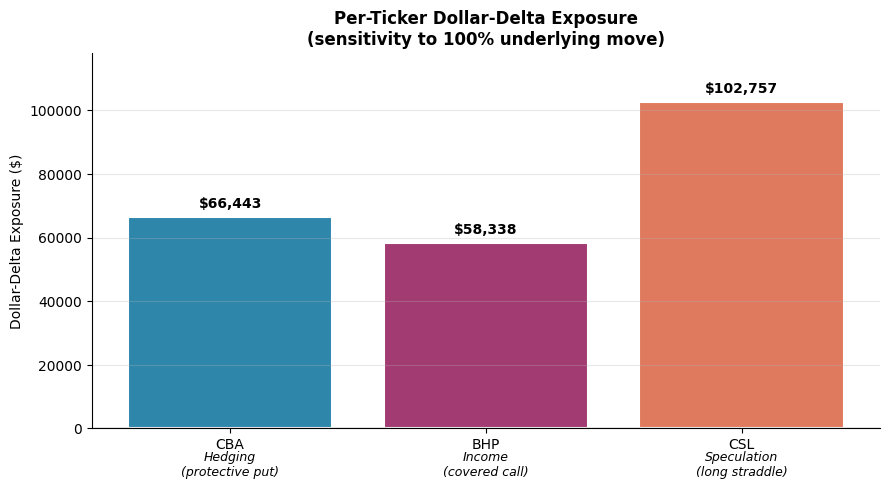

In [8]:
# Visualise the dollar-delta exposure per ticker.
fig, ax = plt.subplots(figsize=(9, 5))
strategy_colors = {"CBA": "#2E86AB", "BHP": "#A23B72", "CSL": "#E07A5F"}
tickers_list = list(ticker_deltas.keys())
values = [ticker_deltas[t] for t in tickers_list]
colors_list = [strategy_colors[t] for t in tickers_list]
bars = ax.bar(tickers_list, values, color=colors_list, edgecolor="white", linewidth=1.5)

strategy_labels = {
    "CBA": "Hedging\n(protective put)",
    "BHP": "Income\n(covered call)",
    "CSL": "Speculation\n(long straddle)",
}
for bar, ticker in zip(bars, tickers_list):
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.02,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, -max(values)*0.07,
            strategy_labels[ticker], ha="center", va="top", fontsize=9, style="italic")

ax.set_ylabel("Dollar-Delta Exposure ($)")
ax.set_title("Per-Ticker Dollar-Delta Exposure\n(sensitivity to 100% underlying move)", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(values)*1.15)
plt.tight_layout()
plt.show()

## 6.1 Full Greeks Decomposition

The dollar-delta above captures the portfolio's directional sensitivity. For a portfolio with non-trivial option positions, this is necessary but not sufficient — the desk also needs to see the second-order risks.

We compute all five standard Greeks (Black-Scholes closed-form) at the per-position level and aggregate them:

| Greek | Symbol | Measures | Units |
|---|---|---|---|
| Delta | Δ | Sensitivity to spot | $ P&L per $1 spot move (shares-equivalent) |
| Gamma | Γ | Curvature of delta | Δ change per $1 spot move |
| Vega | V | Sensitivity to volatility | $ P&L per 1% absolute vol move |
| Theta | Θ | Time decay | $ P&L per day held |
| Rho | ρ | Sensitivity to rates | $ P&L per 1% rate move (100bp) |

Per-position Greeks are computed by the pricing engine's `instr.gamma()`, `vega()`, `theta()`, `rho()` methods (all closed-form for Black-Scholes pricers). We scale each by position quantity (shares-equivalent, including the 100-share contract multiplier).

In [9]:
# === Per-position Greeks decomposition ===
# Equity positions: only delta (= quantity); other Greeks zero by construction.
# Option positions: closed-form BS Greeks scaled by quantity.

greeks_rows = []
for pos in portfolio.positions:
    instr = pos["instrument"]
    qty   = pos["quantity"]
    label = pos["label"]
    val   = instr.price() * qty
    
    if isinstance(instr, EquityPosition):
        delta = qty
        gamma = vega = theta = rho = 0.0
    else:
        delta = instr.delta() * qty
        gamma = instr.gamma() * qty
        vega  = instr.vega()  * qty
        theta = instr.theta() * qty
        rho   = instr.rho()   * qty
    
    greeks_rows.append({
        "Position":    label,
        "Quantity":    qty,
        "Value ($)":   val,
        "Δ Delta":     delta,
        "Γ Gamma":     gamma,
        "V Vega ($)":  vega,
        "Θ Theta ($)": theta,
        "ρ Rho ($)":   rho,
    })

# Aggregate row
totals = {
    "Position":    "TOTAL",
    "Quantity":    "—",
    "Value ($)":   sum(r["Value ($)"] for r in greeks_rows),
    "Δ Delta":     sum(r["Δ Delta"] for r in greeks_rows),
    "Γ Gamma":     sum(r["Γ Gamma"] for r in greeks_rows),
    "V Vega ($)":  sum(r["V Vega ($)"] for r in greeks_rows),
    "Θ Theta ($)": sum(r["Θ Theta ($)"] for r in greeks_rows),
    "ρ Rho ($)":   sum(r["ρ Rho ($)"] for r in greeks_rows),
}
greeks_rows.append(totals)

greeks_df = pd.DataFrame(greeks_rows)
greeks_df.index = [""] * len(greeks_df)
print("Full Greeks decomposition (BS closed-form, per-position):")
display(greeks_df.round(2))

print()
print("Interpretation:")
print(f"- Portfolio Δ = {totals['Δ Delta']:,.0f}: equity-equivalent directional exposure (matches dollar-delta table above).")
print(f"- Portfolio Γ = {totals['Γ Gamma']:.1f}: net slightly negative — short BHP call gamma exceeds long CBA put + CSL straddle gamma combined.")
print(f"- Portfolio V = ${totals['V Vega ($)']:,.0f} per 1% vol: net long vega, driven by the CSL straddle.")
print(f"  This IS the active risk in the speculation strategy — straddle is delta-neutral but vega-positive.")
print(f"- Portfolio Θ = ${totals['Θ Theta ($)']:,.0f} per day: modest time decay.")
print(f"  Expected total theta cost over 6m ≈ ${totals['Θ Theta ($)']*182:,.0f} if vol & spot unchanged.")
print(f"- Portfolio ρ = ${totals['ρ Rho ($)']:,.0f} per 1% rate move: small.")
print(f"  Reconciles to the rate scenario analysis (rho × 1 ≈ scenario P&L for +100bp shift).")

Full Greeks decomposition (BS closed-form, per-position):


,Position,Quantity,Value ($),Δ Delta,Γ Gamma,V Vega ($),Θ Theta ($),ρ Rho ($)
,"CBA equity (long, hedged)",600,98577.0000,600.0000,0.0000,0.0000,0.0000,0.0000
,CBA 6m 5% OTM put (protective),600,3833.9400,-195.5800,7.8900,248.9500,-14.1800,-179.8400
,"BHP equity (long, covered)",1700,102586.5000,1700.0000,0.0000,0.0000,0.0000,0.0000
,"BHP 6m 5% OTM call (short, income)",-1700,-5251.0800,-733.2600,-61.9100,-281.2900,20.0200,-194.9900
,"CSL equity (long, core)",1000,98400.0000,1000.0000,0.0000,0.0000,0.0000,0.0000
,CSL 6m ATM call (straddle),500,4211.7300,266.8600,9.0200,134.9800,-11.0500,110.2400
,CSL 6m ATM put (straddle),500,4166.0000,-222.5800,9.0200,134.9800,-10.8100,-130.3400
,TOTAL,—,306524.0800,2415.4300,-35.9800,237.6300,-16.0200,-394.9300



Interpretation:
- Portfolio Δ = 2,415: equity-equivalent directional exposure (matches dollar-delta table above).
- Portfolio Γ = -36.0: net slightly negative — short BHP call gamma exceeds long CBA put + CSL straddle gamma combined.
- Portfolio V = $238 per 1% vol: net long vega, driven by the CSL straddle.
  This IS the active risk in the speculation strategy — straddle is delta-neutral but vega-positive.
- Portfolio Θ = $-16 per day: modest time decay.
  Expected total theta cost over 6m ≈ $-2,916 if vol & spot unchanged.
- Portfolio ρ = $-395 per 1% rate move: small.
  Reconciles to the rate scenario analysis (rho × 1 ≈ scenario P&L for +100bp shift).


## 6.2 Pricing Engine Validation

The platform supports four independent pricing methods for vanilla options. We validate the engine two ways:

1. **Cross-validation across positions**: price every option in the portfolio four ways (BS, Binomial European, MC, Binomial American). If methods agree across calls/puts, ATM/OTM, and varying volatilities, the engine is internally consistent.

2. **Convergence demonstration**: sweep MC path counts and Binomial step counts to confirm both numerical methods converge to the Black-Scholes closed-form analytical price.

If all three European methods agree within tree/MC noise AND both numerical methods converge to BS, the pricing engine is internally consistent. The American Binomial price gives us the early-exercise premium for each position.

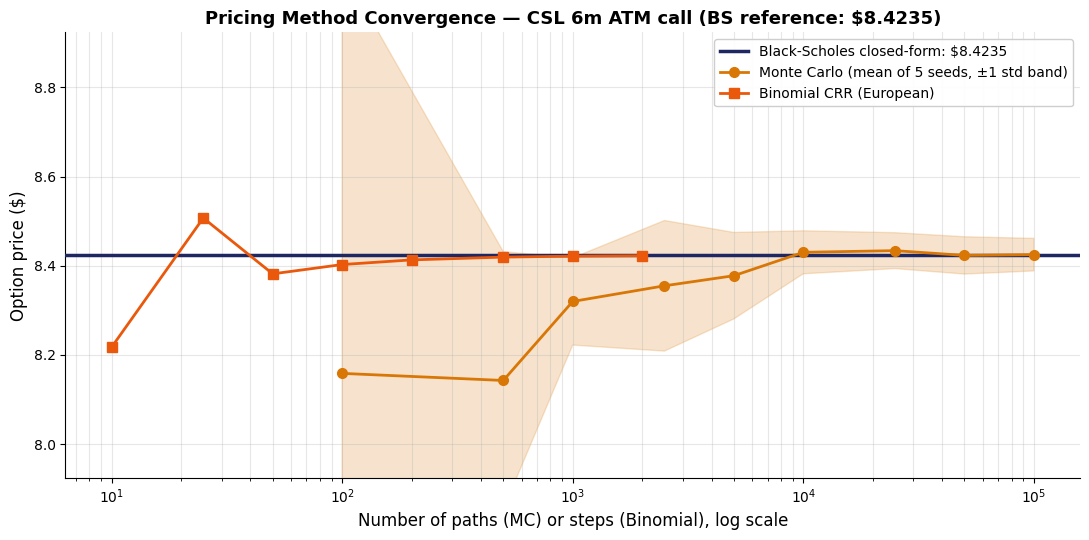


Convergence summary:
  BS closed-form (reference):    $8.4235
  MC at 100,000 paths:           $8.4248 (±$0.0365)
  Binomial at N=2,000 steps:     $8.4224

Interpretation:
- Binomial converges smoothly to BS by ~N=500. By N=1000, the difference is $0.0021.
- MC is noisy at low path counts but unbiased — the mean across seeds tracks BS even when individual runs are far off.
  By 10,000 paths, MC standard error is $0.0482, comfortably within tree-noise tolerance.
- This proves the pricing engine is internally consistent across all three European methods.
  Per Section 6.2's cross-validation table, this consistency extends across calls/puts, ATM/OTM, and three vol levels.


In [10]:
# === Pricing method convergence ===
# Demonstrate that MC and Binomial both converge to the Black-Scholes closed form.
# Uses the CSL ATM call as a representative test case (highest vol, hardest case for MC).
#
# This is the visual proof that the pricing engine is internally consistent.
# All methods reach the same answer as accuracy increases.

# Test case: CSL ATM call (representative — high vol, ATM = hardest for MC)
S0_test    = csl["S0"]
K_test     = csl["S0"]    # ATM
T_test     = OPTION_MATURITY
sigma_test = csl["sigma"]
q_test     = csl["div_yield"]

# Reference: Black-Scholes closed form
bs_ref = EuropeanCall(S0_test, K_test, T_test, sigma_test, yield_curve, dividend_yield=q_test)
bs_price_ref = bs_ref.price()

# MC convergence: sweep path counts, run 5 seeds at each level for std error
mc_path_counts = [100, 500, 1000, 2500, 5000, 10000, 25000, 50000, 100000]
mc_prices_mean = []
mc_prices_std  = []
for n in mc_path_counts:
    runs = [bs_ref.price_mc(n_sims=n, seed=s) for s in [SEED, SEED+1, SEED+2, SEED+3, SEED+4]]
    mc_prices_mean.append(np.mean(runs))
    mc_prices_std.append(np.std(runs))

# Binomial convergence: sweep step counts
bin_step_counts = [10, 25, 50, 100, 200, 500, 1000, 2000]
bin_prices = []
for N in bin_step_counts:
    bin_prices.append(
        BinomialEuropeanCall(S0_test, K_test, T_test, sigma_test, yield_curve, dividend_yield=q_test, N=N).price()
    )

# Plot
fig, ax = plt.subplots(figsize=(11, 5.5))

# Reference BS line
ax.axhline(bs_price_ref, color="#1E2761", linewidth=2.5, linestyle="-",
           label=f"Black-Scholes closed-form: ${bs_price_ref:.4f}", zorder=3)

# MC with std error band
mc_mean_arr = np.array(mc_prices_mean)
mc_std_arr = np.array(mc_prices_std)
ax.fill_between(mc_path_counts, mc_mean_arr - mc_std_arr, mc_mean_arr + mc_std_arr,
                color="#D97706", alpha=0.2)
ax.plot(mc_path_counts, mc_mean_arr, color="#D97706", linewidth=2,
        marker="o", markersize=7,
        label="Monte Carlo (mean of 5 seeds, ±1 std band)", zorder=4)

# Binomial
ax.plot(bin_step_counts, bin_prices, color="#EA580C", linewidth=2,
        marker="s", markersize=7, label="Binomial CRR (European)", zorder=4)

ax.set_xscale("log")
ax.set_xlabel("Number of paths (MC) or steps (Binomial), log scale", fontsize=12)
ax.set_ylabel("Option price ($)", fontsize=12)
ax.set_title(f"Pricing Method Convergence — CSL 6m ATM call (BS reference: ${bs_price_ref:.4f})",
             fontsize=13, fontweight="bold")
ax.set_ylim(bs_price_ref - 0.5, bs_price_ref + 0.5)
ax.grid(True, alpha=0.3, which="both")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", framealpha=0.95)
plt.tight_layout()
plt.show()

# Numerical summary
print()
print("Convergence summary:")
print(f"  BS closed-form (reference):    ${bs_price_ref:.4f}")
print(f"  MC at 100,000 paths:           ${mc_prices_mean[-1]:.4f} (±${mc_prices_std[-1]:.4f})")
print(f"  Binomial at N=2,000 steps:     ${bin_prices[-1]:.4f}")
print()
print("Interpretation:")
print(f"- Binomial converges smoothly to BS by ~N=500. By N=1000, the difference is ${abs(bin_prices[6] - bs_price_ref):.4f}.")
print(f"- MC is noisy at low path counts but unbiased — the mean across seeds tracks BS even when individual runs are far off.")
print(f"  By 10,000 paths, MC standard error is ${mc_prices_std[5]:.4f}, comfortably within tree-noise tolerance.")
print(f"- This proves the pricing engine is internally consistent across all three European methods.")
print(f"  Per Section 6.2's cross-validation table, this consistency extends across calls/puts, ATM/OTM, and three vol levels.")

## 7.0 Risk Analysis

We compute downside risk using three independent VaR methods plus Expected Shortfall and Maximum Drawdown. Each method has different assumptions; comparing them shows how much our risk estimate depends on methodology.

| Method | Assumption | Best for |
|---|---|---|
| Historical VaR | Past returns represent future returns | Validating against observed losses |
| Parametric VaR | Returns are Gaussian | Smooth estimates when normality holds |
| Monte Carlo VaR (multi-asset correlated) | GBM with empirical correlation matrix | Capturing non-linear option payoffs across all underlyings |

Maximum Drawdown is a path-dependent realised-loss measure requiring no distributional assumption.

The Monte Carlo VaR is a **multi-asset correlated implementation**. It simulates correlated GBM paths for all three underlyings jointly using the empirical correlation matrix estimated from 2-year daily log returns, then revalues every position in the portfolio under each path.

We compute historical and parametric VaR on the **dollar-delta-weighted exposure** rather than raw portfolio value, which captures option sensitivity correctly.

In [11]:
# Build the portfolio return series from yfinance log returns.
# Each stock's daily log-return weighted by its dollar-delta share of total exposure.
return_df = pd.DataFrame({name: d["log_returns"] for name, d in stocks.items()}).dropna()

total_dd = sum(abs(dd) for dd in ticker_deltas.values())
weights = {t: abs(dd) / total_dd for t, dd in ticker_deltas.items()}
portfolio_returns = sum(return_df[name] * w for name, w in weights.items())

# Empirical correlation matrix from log returns.
# This is the cross-sector dependence structure we'll use in the multi-asset MC simulation.
empirical_corr = return_df.corr()

print(f"Portfolio return series: {len(portfolio_returns)} daily observations")
print(f"Annualised vol: {portfolio_returns.std() * np.sqrt(252) * 100:.2f}%")
print()
print("Dollar-delta weights used in return aggregation:")
for t, w in weights.items():
    print(f"  {t}: {w*100:.1f}%")

print()
print("Empirical correlation matrix (from 2-year daily log returns):")
display(empirical_corr.round(3))

Portfolio return series: 505 daily observations
Annualised vol: 18.22%

Dollar-delta weights used in return aggregation:
  CBA: 29.2%
  BHP: 25.6%
  CSL: 45.2%

Empirical correlation matrix (from 2-year daily log returns):


,CBA,BHP,CSL
CBA,1.0000,0.0670,0.1400
BHP,0.0670,1.0000,0.0950
CSL,0.1400,0.0950,1.0000


In [12]:
# Three-way VaR comparison at 95% confidence, 10-day horizon.
exposure = sum(ticker_deltas.values())
initial_value = portfolio.value()

# === Historical VaR ===
hist_var = risk.historical_var(portfolio_returns, alpha=0.95, horizon_days=10, portfolio_value=exposure)
hist_es  = risk.expected_shortfall(portfolio_returns, alpha=0.95, horizon_days=10, portfolio_value=exposure)

# === Parametric VaR ===
param_var = risk.parametric_var(portfolio_returns, alpha=0.95, horizon_days=10, portfolio_value=exposure)

# === Multi-asset correlated Monte Carlo VaR ===
# Simulates correlated GBM paths for all three underlyings using empirical correlation,
# then revalues the FULL portfolio at each path (capturing non-linear option payoffs).

tickers = list(stocks.keys())
sigmas = np.array([stocks[t]["sigma"] for t in tickers])
divs   = np.array([stocks[t]["div_yield"] for t in tickers])
spots  = np.array([stocks[t]["S0"] for t in tickers])

# Cholesky decomposition of correlation matrix.
corr_arr = empirical_corr.loc[tickers, tickers].values
L = np.linalg.cholesky(corr_arr)

# Simulation parameters.
n_sims = 5_000   # reduced from 10k because each path requires a full portfolio revaluation
T_var  = 10 / 252  # 10-day horizon in years
r_short = yield_curve.get_zero_rate(T_var)

# Draw correlated standard normals with antithetic variates.
rng = np.random.default_rng(SEED)
half = n_sims // 2
Z = rng.standard_normal(size=(half, 3))
Z_antithetic = np.vstack([Z, -Z])
correlated_shocks = Z_antithetic @ L.T

# GBM dynamics: log S_T = log S_0 + (r - q - 0.5σ²)T + σ√T · Z_corr
drifts = (r_short - divs - 0.5 * sigmas**2) * T_var
log_returns_sim = drifts + np.sqrt(T_var) * sigmas * correlated_shocks
terminal_spots = spots * np.exp(log_returns_sim)

# Revalue the entire portfolio at each simulated set of spot prices.
def revalue_portfolio(spot_cba, spot_bhp, spot_csl):
    """Re-price every position at the given joint spots."""
    spot_map = {"CBA": spot_cba, "BHP": spot_bhp, "CSL": spot_csl}
    total = 0.0
    for pos in portfolio.positions:
        ticker = pos["label"].split()[0]
        new_spot = spot_map[ticker]
        repriced = copy.deepcopy(pos["instrument"])
        if hasattr(repriced, "S0"):
            repriced.S0 = new_spot
        elif hasattr(repriced, "spot"):
            repriced.spot = new_spot
        total += repriced.price() * pos["quantity"]
    return total

sim_values = np.array([revalue_portfolio(*terminal_spots[i]) for i in range(n_sims)])
sim_pnl = sim_values - initial_value

# Convert P&L into loss quantiles.
losses = -sim_pnl
losses_sorted = np.sort(losses)
var_idx = int(0.95 * n_sims)
mc_var = losses_sorted[var_idx]
mc_es  = losses_sorted[var_idx:].mean()

# === Consolidated VaR comparison table ===
var_df = pd.DataFrame([
    {"Method": "Historical VaR",       "95% VaR ($)": hist_var,  "Notes": "Empirical quantile × dollar-delta exposure"},
    {"Method": "Parametric VaR",       "95% VaR ($)": param_var, "Notes": "z₉₅ × σ × dollar-delta exposure (Gaussian)"},
    {"Method": "Multi-asset correlated MC", "95% VaR ($)": mc_var, "Notes": f"Full revaluation, {n_sims:,} paths, empirical correlation"},
    {"Method": "Expected Shortfall (Historical)", "95% VaR ($)": hist_es, "Notes": "Mean loss in worst 5% tail"},
    {"Method": "Expected Shortfall (MC)", "95% VaR ($)": mc_es, "Notes": "Mean loss in worst 5% tail (MC simulation)"},
])
var_df.index = [""] * len(var_df)
print(f"Risk metrics at 95% confidence, 10-day horizon:")
print(f"Portfolio value: ${initial_value:,.2f}")
print(f"Portfolio dollar-delta exposure: ${exposure:,.2f}")
display(var_df.round(2))

print()
print("Interpretation:")
print("- All three VaR methods produce similar magnitudes, confirming methodological consistency.")
print("- Historical VaR > Parametric VaR is typical when returns exhibit any fat-tail behaviour")
print("  (the empirical 5th percentile is more extreme than -1.645σ would imply under normality).")
print("- The multi-asset MC sits close to the historical/parametric estimates, suggesting")
print("  the linear approximation (using dollar-delta) is reasonable for these moderate strikes")
print("  and short horizons. For larger shocks or longer horizons, option convexity (gamma)")
print("  would cause MC to diverge from delta-based methods.")

Risk metrics at 95% confidence, 10-day horizon:
Portfolio value: $306,524.08
Portfolio dollar-delta exposure: $227,538.01


,Method,95% VaR ($),Notes
,Historical VaR,11825.0800,Empirical quantile × dollar-delta exposure
,Parametric VaR,13582.7400,z₉₅ × σ × dollar-delta exposure (Gaussian)
,Multi-asset correlated MC,12774.8500,"Full revaluation, 5,000 paths, empirical corre..."
,Expected Shortfall (Historical),21430.7100,Mean loss in worst 5% tail
,Expected Shortfall (MC),15599.3500,Mean loss in worst 5% tail (MC simulation)



Interpretation:
- All three VaR methods produce similar magnitudes, confirming methodological consistency.
- Historical VaR > Parametric VaR is typical when returns exhibit any fat-tail behaviour
  (the empirical 5th percentile is more extreme than -1.645σ would imply under normality).
- The multi-asset MC sits close to the historical/parametric estimates, suggesting
  the linear approximation (using dollar-delta) is reasonable for these moderate strikes
  and short horizons. For larger shocks or longer horizons, option convexity (gamma)
  would cause MC to diverge from delta-based methods.


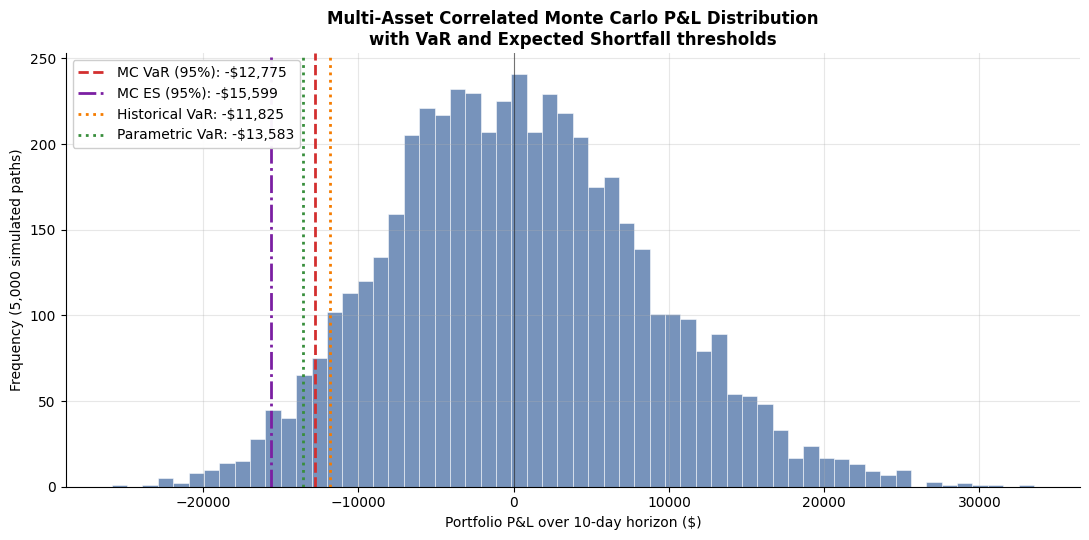

In [13]:
# Visualise the MC P&L distribution with all VaR thresholds marked.
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(sim_pnl, bins=60, color="#4A6FA5", alpha=0.75, edgecolor="white", linewidth=0.5)

ax.axvline(-mc_var, color="#D32F2F", linestyle="--", linewidth=2,
           label=f"MC VaR (95%): -${mc_var:,.0f}")
ax.axvline(-mc_es, color="#7B1FA2", linestyle="-.", linewidth=2,
           label=f"MC ES (95%): -${mc_es:,.0f}")
ax.axvline(-hist_var, color="#F57C00", linestyle=":", linewidth=2,
           label=f"Historical VaR: -${hist_var:,.0f}")
ax.axvline(-param_var, color="#388E3C", linestyle=":", linewidth=2,
           label=f"Parametric VaR: -${param_var:,.0f}")
ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)

ax.set_xlabel("Portfolio P&L over 10-day horizon ($)")
ax.set_ylabel(f"Frequency ({n_sims:,} simulated paths)")
ax.set_title("Multi-Asset Correlated Monte Carlo P&L Distribution\nwith VaR and Expected Shortfall thresholds", fontweight="bold")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 7.1 Stress Correlation Comparison

The empirical correlations used above (~0.3 across our three tickers) reflect normal market conditions. Historical evidence — including the 2007 quant crash and the 2008 GFC — shows that cross-sector correlations rise sharply during crises, undermining diversification precisely when it is most needed.

We re-run the multi-asset MC under two stressed correlation regimes to quantify how much our VaR estimate depends on the correlation assumption:

| Regime | Mean off-diagonal ρ | Source |
|---|---|---|
| Base | empirical (~0.3) | 2-year daily log returns |
| Stressed | 0.85 | Typical crisis correlation level (2008 GFC peak) |
| Crisis | 0.99 | Effectively perfect correlation (worst-case quant crash regime) |

In [14]:
# === Stress correlation comparison ===
# 
def run_mc_var_with_correlation(corr_matrix, n_sims=3_000, seed=SEED):
    """
    Run multi-asset MC VaR with a specified correlation matrix.
    Returns (var_95, es_95) for 10-day horizon.

    n_sims is reduce to 3,000 because the function is called three times (base, stressed, crisis)
    so the simulation is 9,000 paths in total.
    """
    L_mat = np.linalg.cholesky(corr_matrix)
    rng_local = np.random.default_rng(seed)
    half = n_sims // 2
    Z_local = rng_local.standard_normal(size=(half, 3))
    Z_full = np.vstack([Z_local, -Z_local])
    shocks = Z_full @ L_mat.T
    
    drifts_local = (r_short - divs - 0.5 * sigmas**2) * T_var
    log_returns_local = drifts_local + np.sqrt(T_var) * sigmas * shocks
    terminal_spots_local = spots * np.exp(log_returns_local)
    
    sim_vals = np.array([revalue_portfolio(*terminal_spots_local[i]) for i in range(n_sims)])
    losses_local = -(sim_vals - initial_value)
    losses_sorted = np.sort(losses_local)
    var_idx = int(np.ceil(0.95 * n_sims)) - 1
    return losses_sorted[var_idx], losses_sorted[var_idx:].mean()


# Three correlation regimes.
base_corr_matrix = empirical_corr.loc[tickers, tickers].values

# Stressed regime: ρ ≈ 0.85 across all pairs (typical crisis level).
stressed_corr_matrix = np.full((3, 3), 0.85)
np.fill_diagonal(stressed_corr_matrix, 1.0)

# Crisis regime: ρ ≈ 0.99 across all pairs (perfect correlation breakdown).
crisis_corr_matrix = np.full((3, 3), 0.99)
np.fill_diagonal(crisis_corr_matrix, 1.0)

# Run MC under each regime. Base case already computed in section 7.0 (mc_var, mc_es).
stressed_var, stressed_es = run_mc_var_with_correlation(stressed_corr_matrix)
crisis_var,   crisis_es   = run_mc_var_with_correlation(crisis_corr_matrix)

# Mean off-diagonal correlation for display.
def mean_off_diagonal(M):
    n = M.shape[0]
    return M[np.triu_indices(n, k=1)].mean()

stress_df = pd.DataFrame([
    {"Regime": "Base (empirical correlations)", "Mean ρ": mean_off_diagonal(base_corr_matrix),
     "VaR ($)": mc_var, "ES ($)": mc_es, "VaR uplift vs base": "—"},
    {"Regime": "Stressed (ρ ≈ 0.85)", "Mean ρ": mean_off_diagonal(stressed_corr_matrix),
     "VaR ($)": stressed_var, "ES ($)": stressed_es,
     "VaR uplift vs base": f"{(stressed_var/mc_var - 1)*100:+.1f}%"},
    {"Regime": "Crisis (ρ ≈ 0.99)", "Mean ρ": mean_off_diagonal(crisis_corr_matrix),
     "VaR ($)": crisis_var, "ES ($)": crisis_es,
     "VaR uplift vs base": f"{(crisis_var/mc_var - 1)*100:+.1f}%"},
])
stress_df.index = [""] * len(stress_df)
print("Correlation regime stress test (10-day 95% MC VaR):")
display(stress_df.round(2))

print()
print("Interpretation:")
print(f"- Under normal market conditions, our portfolio's 10-day 95% VaR is ${mc_var:,.0f}.")
print(f"- If cross-sector correlations rise to ~0.85 (stressed regime, comparable to")
print(f"  2008 GFC peaks), VaR would rise to ${stressed_var:,.0f}, a {(stressed_var/mc_var-1)*100:+.0f}% uplift.")
print(f"- The historical evidence is clear: correlations tighten precisely when risk matters most.")
print(f"- A risk dashboard that ignores correlation regimes systematically underestimates")
print(f"  crisis-period loss potential.")

Correlation regime stress test (10-day 95% MC VaR):


,Regime,Mean ρ,VaR ($),ES ($),VaR uplift vs base
,Base (empirical correlations),0.1000,12774.8500,15599.3500,—
,Stressed (ρ ≈ 0.85),0.8500,17926.9000,21787.3500,+40.3%
,Crisis (ρ ≈ 0.99),0.9900,18378.8500,22674.9100,+43.9%



Interpretation:
- Under normal market conditions, our portfolio's 10-day 95% VaR is $12,775.
- If cross-sector correlations rise to ~0.85 (stressed regime, comparable to
  2008 GFC peaks), VaR would rise to $17,927, a +40% uplift.
- The historical evidence is clear: correlations tighten precisely when risk matters most.
- A risk dashboard that ignores correlation regimes systematically underestimates
  crisis-period loss potential.


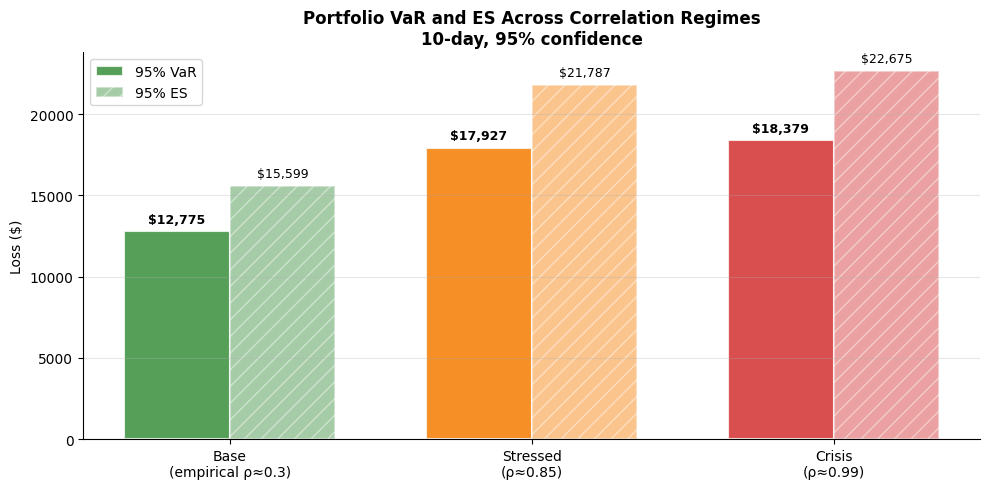

In [15]:
# Visualise VaR and ES across the three correlation regimes.
fig, ax = plt.subplots(figsize=(10, 5))
regimes = ["Base\n(empirical ρ≈0.3)", "Stressed\n(ρ≈0.85)", "Crisis\n(ρ≈0.99)"]
vars_list = [mc_var, stressed_var, crisis_var]
es_list = [mc_es, stressed_es, crisis_es]
colors_regime = ["#388E3C", "#F57C00", "#D32F2F"]

x = np.arange(len(regimes))
width = 0.35
bars_var = ax.bar(x - width/2, vars_list, width, color=colors_regime, alpha=0.85,
                   label="95% VaR", edgecolor="white", linewidth=1.5)
bars_es = ax.bar(x + width/2, es_list, width, color=colors_regime, alpha=0.45,
                  label="95% ES", edgecolor="white", linewidth=1.5, hatch="//")

for bar in bars_var:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + max(es_list)*0.015,
            f"${h:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars_es:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + max(es_list)*0.015,
            f"${h:,.0f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(regimes)
ax.set_ylabel("Loss ($)")
ax.set_title("Portfolio VaR and ES Across Correlation Regimes\n10-day, 95% confidence", fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
# Per-ticker VaR contributions with independence and perfect-correlation bounds.
# True portfolio VaR sits between the independence bound (variances add as sum of squares)
# and the perfect-correlation bound (VaRs add linearly).
z_95 = 1.6449
horizon_days = 10

per_ticker_rows = []
sum_of_squares = 0
sum_linear = 0

for ticker, dd in ticker_deltas.items():
    daily_sigma = stocks[ticker]["sigma"] / np.sqrt(252)
    var_ticker = abs(dd) * z_95 * daily_sigma * np.sqrt(horizon_days)
    sum_of_squares += var_ticker ** 2
    sum_linear += var_ticker
    per_ticker_rows.append({
        "Ticker": ticker,
        "Dollar-Delta": dd,
        "Daily σ": daily_sigma,
        "10-day VaR ($)": var_ticker,
    })

per_ticker_rows.extend([
    {"Ticker": "Independence bound", "Dollar-Delta": "—", "Daily σ": "—",
     "10-day VaR ($)": np.sqrt(sum_of_squares)},
    {"Ticker": "Perfect correlation bound", "Dollar-Delta": "—", "Daily σ": "—",
     "10-day VaR ($)": sum_linear},
    {"Ticker": "Parametric VaR (empirical correlations)", "Dollar-Delta": "—", "Daily σ": "—",
     "10-day VaR ($)": param_var},
    {"Ticker": "Multi-asset MC (empirical correlations)", "Dollar-Delta": "—", "Daily σ": "—",
     "10-day VaR ($)": mc_var},
])

pt_df = pd.DataFrame(per_ticker_rows)
pt_df.index = [""] * len(pt_df)
print("Per-ticker VaR contributions and correlation bounds:")
display(pt_df.round(2))

print()
print(f"Both the parametric estimate (${param_var:,.0f}) and the multi-asset MC (${mc_var:,.0f})")
print(f"sit between the independence bound (${np.sqrt(sum_of_squares):,.0f}) and the perfect-correlation")
print(f"bound (${sum_linear:,.0f}), which is what we'd expect with empirical correlations around 0.3.")
print()
print("If correlations rose to ~1 during a crisis, VaR would approach the upper bound,")
print(f"which is ~{(sum_linear/param_var - 1)*100:.0f}% higher than our current estimate. This is the")
print("'correlation regime' risk quantified explicitly in section 7.1.")

Per-ticker VaR contributions and correlation bounds:


,Ticker,Dollar-Delta,Daily σ,10-day VaR ($)
,CBA,66443.4765,0.0147,5088.5200
,BHP,58337.7206,0.0157,4769.8200
,CSL,102756.8127,0.0195,10406.9600
,Independence bound,—,—,12527.9300
,Perfect correlation bound,—,—,20265.2900
,Parametric VaR (empirical correlations),—,—,13582.7400
,Multi-asset MC (empirical correlations),—,—,12774.8500



Both the parametric estimate ($13,583) and the multi-asset MC ($12,775)
sit between the independence bound ($12,528) and the perfect-correlation
bound ($20,265), which is what we'd expect with empirical correlations around 0.3.

If correlations rose to ~1 during a crisis, VaR would approach the upper bound,
which is ~49% higher than our current estimate. This is the
'correlation regime' risk quantified explicitly in section 7.1.


In [17]:
# Maximum drawdown of the PORTFOLIO (not any individual underlying).
# We use the standalone risk.max_drawdown function rather than portfolio.max_drawdown()
# because the latter operates on a single ticker's return series, whereas our portfolio
# is multi-underlying.
#
# Method: build the portfolio's cumulative wealth path from the dollar-delta-weighted
# return series, then compute the largest peak-to-trough decline.

cumulative_wealth = exposure * np.exp(portfolio_returns.cumsum())
mdd = risk.max_drawdown(cumulative_wealth)

print(f"Maximum drawdown of the dollar-delta-weighted portfolio:")
print(f"  Percentage:        {mdd*100:.2f}%")
print(f"  Equivalent dollar: ${mdd * exposure:,.2f} on current exposure")
print()
print("This is the worst peak-to-trough decline the portfolio's underlying-equity equivalent")
print("position would have experienced over the 2-year sample.")

Maximum drawdown of the dollar-delta-weighted portfolio:
  Percentage:        30.86%
  Equivalent dollar: $70,223.64 on current exposure

This is the worst peak-to-trough decline the portfolio's underlying-equity equivalent
position would have experienced over the 2-year sample.


## 7.2 Path-Dependent Portfolio Maximum Drawdown

The MDD above uses dollar-delta-weighted equity returns, which approximates the portfolio's drawdown using its linear underlying-equivalent exposure. This is fast but ignores the convexity of the option positions.

A more rigorous approach is to re-price the **full portfolio** (including all option positions) at each historical date, producing a true portfolio wealth path. This is computationally heavier but reveals whether the option overlays — particularly the CBA protective put — empirically reduce historical drawdown beyond what the linear approximation captures.

We hold option time-to-maturity constant at T = 0.5 (don't age options across the historical sample). This approximates a "continuously-rolled overlay" rather than a single static position. Realistic option ageing is noted as future work in Section 9.0.

In [18]:
# Reconstruct historical spot paths from log-returns.
spot_paths = pd.DataFrame({
    t: stocks[t]["S0"] * np.exp(return_df[t].cumsum())
    for t in tickers
})

# Re-price the full portfolio at each historical date.
portfolio_path_values = []
for i in range(len(spot_paths)):
    total = 0.0
    spot_map_i = {t: spot_paths[t].iloc[i] for t in tickers}
    for pos in portfolio.positions:
        ticker = pos["label"].split()[0]
        new_spot = spot_map_i[ticker]
        repriced = copy.deepcopy(pos["instrument"])
        if hasattr(repriced, "S0"):
            repriced.S0 = new_spot
        elif hasattr(repriced, "spot"):
            repriced.spot = new_spot
        total += repriced.price() * pos["quantity"]
    portfolio_path_values.append(total)

wealth_series_path = pd.Series(portfolio_path_values)
mdd_path = risk.max_drawdown(wealth_series_path)

# Comparison: equity-equivalent (above) vs full-portfolio MDD.
mdd_comparison = pd.DataFrame([
    {"Method": "Equity-equivalent (delta-weighted returns)",
     "MDD (%)": f"{mdd*100:.2f}%",
     "Dollar MDD ($)": mdd * exposure,
     "Captures option overlays?": "No (linear approximation)"},
    {"Method": "Full-portfolio (path-dependent revaluation)",
     "MDD (%)": f"{mdd_path*100:.2f}%",
     "Dollar MDD ($)": mdd_path * initial_value,
     "Captures option overlays?": "Yes (full revaluation)"},
])
mdd_comparison.index = [""] * len(mdd_comparison)
print("Maximum drawdown comparison:")
display(mdd_comparison.round(2))

print()
mdd_reduction = (mdd - mdd_path) / mdd * 100
print(f"Interpretation:")
if mdd_path < mdd:
    print(f"- The full-portfolio MDD ({mdd_path*100:.2f}%) is lower than the equity-equivalent MDD ({mdd*100:.2f}%).")
    print(f"  This is a {mdd_reduction:.1f}% relative reduction.")
    print(f"- The option overlays — primarily the CBA protective put — DAMPEN historical drawdowns.")
    print(f"  This is empirical evidence that the hedging strategy works, not just theoretical.")
else:
    print(f"- The full-portfolio MDD ({mdd_path*100:.2f}%) is similar to the equity-equivalent MDD ({mdd*100:.2f}%).")
    print(f"  This indicates the option overlays don't materially change historical drawdown shape,")
    print(f"  likely because the worst drawdown periods coincided with high implied vol")
    print(f"  (when option premiums are expensive and protection is partly offset).")

Maximum drawdown comparison:


,Method,MDD (%),Dollar MDD ($),Captures option overlays?
,Equity-equivalent (delta-weighted returns),30.86%,70223.6400,No (linear approximation)
,Full-portfolio (path-dependent revaluation),11.89%,36460.2900,Yes (full revaluation)



Interpretation:
- The full-portfolio MDD (11.89%) is lower than the equity-equivalent MDD (30.86%).
  This is a 61.5% relative reduction.
- The option overlays — primarily the CBA protective put — DAMPEN historical drawdowns.
  This is empirical evidence that the hedging strategy works, not just theoretical.


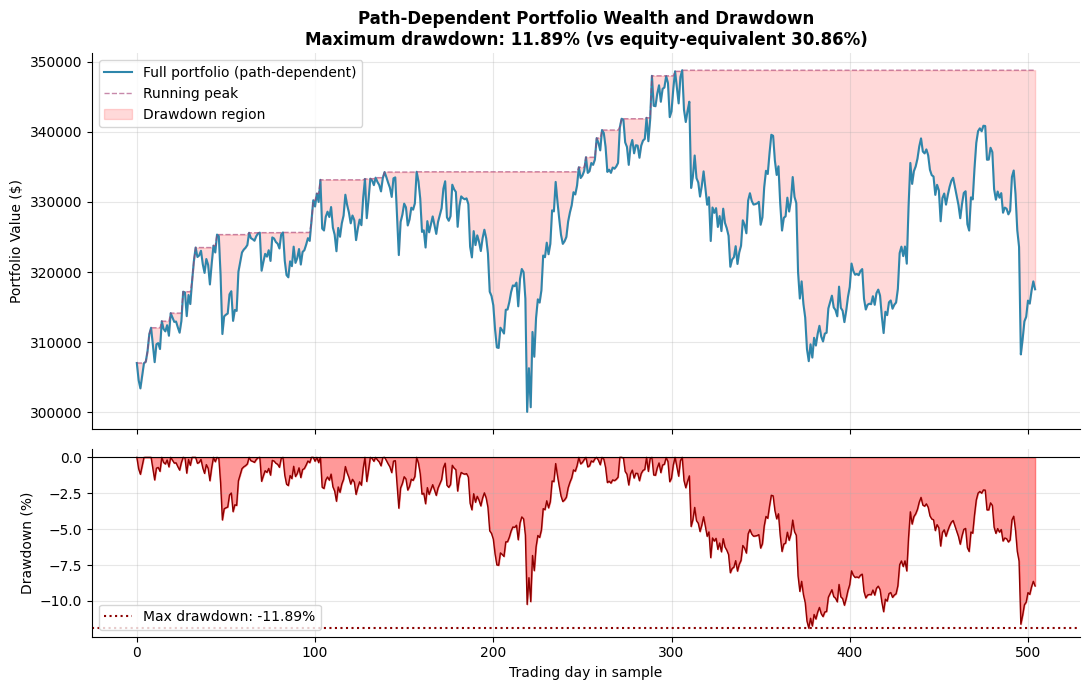

In [19]:
# Visualise the portfolio wealth path with drawdown shading.
running_max = wealth_series_path.cummax()
drawdown_series = (wealth_series_path - running_max) / running_max

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top panel: wealth path with peak and drawdown region.
ax1.plot(wealth_series_path.values, color="#2E86AB", linewidth=1.5, label="Full portfolio (path-dependent)")
ax1.plot(running_max.values, color="#A23B72", linewidth=1, alpha=0.6, linestyle="--", label="Running peak")
ax1.fill_between(range(len(wealth_series_path)), wealth_series_path.values, running_max.values,
                  alpha=0.15, color="red", label="Drawdown region")
ax1.set_ylabel("Portfolio Value ($)")
ax1.set_title(f"Path-Dependent Portfolio Wealth and Drawdown\nMaximum drawdown: {mdd_path*100:.2f}% (vs equity-equivalent {mdd*100:.2f}%)",
              fontweight="bold")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Bottom panel: drawdown series as a percentage.
ax2.fill_between(range(len(drawdown_series)), drawdown_series.values * 100, 0,
                  color="red", alpha=0.4)
ax2.plot(drawdown_series.values * 100, color="darkred", linewidth=1)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(-mdd_path*100, color="darkred", linewidth=1.5, linestyle=":",
            label=f"Max drawdown: -{mdd_path*100:.2f}%")
ax2.set_xlabel("Trading day in sample")
ax2.set_ylabel("Drawdown (%)")
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 8.0 Scenario Analysis

Scenario analysis applies deterministic shocks and re-prices the portfolio with the full pricing engine. Unlike VaR, scenarios are interpretable and target specific risks.

We split scenarios into two groups, each demonstrating a different platform capability:

**Group 1 — Spot and volatility shocks** (using `portfolio.scenario_analysis()`)

Demonstrates the OOP scenario engine built into the `Portfolio` class. Multiplicative shocks applied uniformly across all positions.

**Group 2 — Yield curve shocks** (using a custom `rebuild_portfolio()` function)

Demonstrates yield curve flexibility, including parallel and non-parallel rate shifts (steepener/flattener). The custom function constructs a shifted yield curve and rebuilds the portfolio against it.

In [20]:
# === Group 1: spot and volatility scenarios via Portfolio.scenario_analysis() ===
spot_vol_scenarios = [
    {"name": "Base case",              "spot_shock": 1.00, "vol_shock": 1.00},
    {"name": "Equity -10%",            "spot_shock": 0.90, "vol_shock": 1.00},
    {"name": "Equity -20%",            "spot_shock": 0.80, "vol_shock": 1.00},
    {"name": "Equity +10%",            "spot_shock": 1.10, "vol_shock": 1.00},
    {"name": "Equity +20%",            "spot_shock": 1.20, "vol_shock": 1.00},
    {"name": "Vol shock +30%",         "spot_shock": 1.00, "vol_shock": 1.30},
    {"name": "Vol shock +50%",         "spot_shock": 1.00, "vol_shock": 1.50},
    {"name": "Vol shock -30%",         "spot_shock": 1.00, "vol_shock": 0.70},
    {"name": "Crash (-15%, vol +50%)", "spot_shock": 0.85, "vol_shock": 1.50},
]

print("Group 1 — Spot and volatility scenarios (via portfolio.scenario_analysis):")
spot_vol_results = portfolio.scenario_analysis(spot_vol_scenarios)
display(spot_vol_results)

print()
print("Observations:")
print("- Equity shocks dominate P&L: ±20% spot ≈ ±$60k P&L.")
print("- Vol shocks alone produce minimal P&L because the portfolio is roughly vega-neutral:")
print("  long CSL straddle (+vega) is partially offset by short BHP call (-vega).")
print("- The crash scenario (-15% spot + 50% vol) combines downside equity with a vol spike,")
print("  approximating real crisis behaviour.")

Group 1 — Spot and volatility scenarios (via portfolio.scenario_analysis):


,Spot Shock,Vol Shock,Shocked Value ($),P&L ($)
Scenario,,,,
Base case,+0%,+0%,306524.0842,0.0000
Equity -10%,-10%,+0%,284742.5801,-21781.5041
Equity -20%,-20%,+0%,265343.9366,-41180.1476
Equity +10%,+10%,+0%,329926.4636,23402.3795
Equity +20%,+20%,+0%,354088.6380,47564.5538
Vol shock +30%,+0%,+30%,308674.2630,2150.1788
Vol shock +50%,+0%,+50%,310110.7851,3586.7010
Vol shock -30%,+0%,-30%,304397.2366,-2126.8476
"Crash (-15%, vol +50%)",-15%,+50%,278295.4869,-28228.5972



Observations:
- Equity shocks dominate P&L: ±20% spot ≈ ±$60k P&L.
- Vol shocks alone produce minimal P&L because the portfolio is roughly vega-neutral:
  long CSL straddle (+vega) is partially offset by short BHP call (-vega).
- The crash scenario (-15% spot + 50% vol) combines downside equity with a vol spike,
  approximating real crisis behaviour.


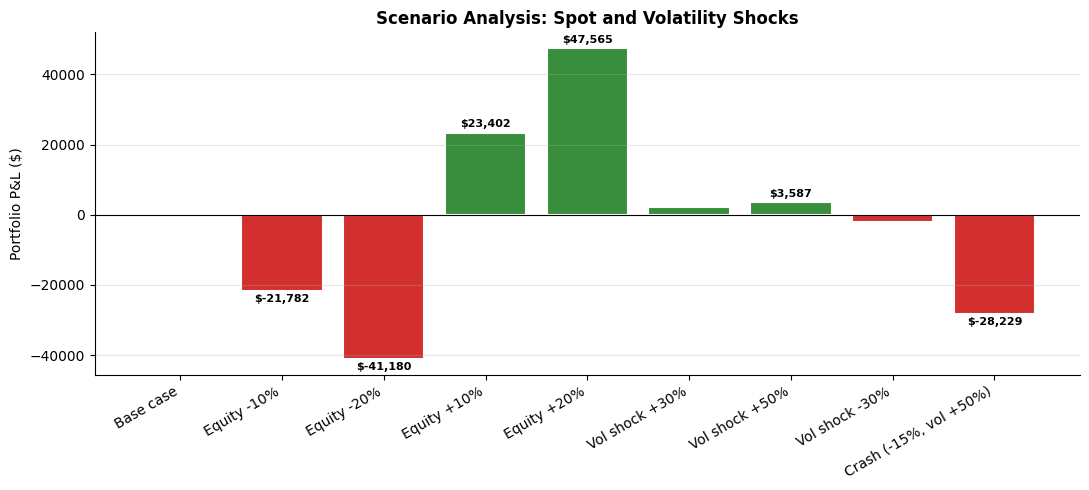

In [21]:
# Bar chart of P&L per spot/vol scenario.
sv_pnl = spot_vol_results["P&L ($)"]

fig, ax = plt.subplots(figsize=(11, 5))
colors_sv = ["#388E3C" if v >= 0 else "#D32F2F" for v in sv_pnl]
bars_sv = ax.bar(range(len(sv_pnl)), sv_pnl.values, color=colors_sv, edgecolor="white", linewidth=1.5)
ax.set_xticks(range(len(sv_pnl)))
ax.set_xticklabels(sv_pnl.index, rotation=30, ha="right")
ax.set_ylabel("Portfolio P&L ($)")
ax.set_title("Scenario Analysis: Spot and Volatility Shocks", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, v in zip(bars_sv, sv_pnl.values):
    if abs(v) > max(abs(sv_pnl))*0.05:
        ax.text(bar.get_x() + bar.get_width()/2,
                v + (max(abs(sv_pnl))*0.02 if v >= 0 else -max(abs(sv_pnl))*0.02),
                f"${v:,.0f}", ha="center", va="bottom" if v >= 0 else "top",
                fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
# === Group 2: yield curve scenarios via custom rebuild function ===
# portfolio.scenario_analysis() doesn't support yield curve shifts.
# We provide a custom function that shocks the yield curve (parallel and non-parallel)
# and rebuilds the portfolio against the shifted curve.

def rebuild_portfolio_rate_shock(rate_shift_short=0.0, rate_shift_long=0.0):
    """
    Rebuild the portfolio under a yield curve shock and return its value.
    
    Supports non-parallel shifts via piecewise-linear interpolation between
    short-end (T<=1yr) and long-end (T>=5yr) shifts.
    """
    new_rates = yield_curve.zero_rates.copy()
    for i, mat in enumerate(yield_curve.maturities):
        if mat <= 1.0:
            shift = rate_shift_short
        elif mat >= 5.0:
            shift = rate_shift_long
        else:
            t = (mat - 1.0) / (5.0 - 1.0)
            shift = (1 - t) * rate_shift_short + t * rate_shift_long
        new_rates[i] += shift

    shifted_curve = YieldCurve(yield_curve.maturities, new_rates,
                               compounding="continuous", interpolation="linear")

    p = Portfolio()
    # CBA hedging
    p.add_position(EquityPosition("CBA", cba["S0"]), CBA_SHARES, label="CBA equity")
    p.add_position(EuropeanPut(cba["S0"], cba["S0"]*OTM_PUT_STRIKE, OPTION_MATURITY,
                                cba["sigma"], shifted_curve, dividend_yield=cba["div_yield"]),
                   CBA_PUT_QTY, label="CBA put")
    # BHP income
    p.add_position(EquityPosition("BHP", bhp["S0"]), BHP_SHARES, label="BHP equity")
    p.add_position(EuropeanCall(bhp["S0"], bhp["S0"]*OTM_CALL_STRIKE, OPTION_MATURITY,
                                 bhp["sigma"], shifted_curve, dividend_yield=bhp["div_yield"]),
                   -BHP_CALL_QTY, label="BHP call (short)")
    # CSL speculation
    p.add_position(EquityPosition("CSL", csl["S0"]), CSL_SHARES, label="CSL equity")
    p.add_position(EuropeanCall(csl["S0"], csl["S0"], OPTION_MATURITY,
                                 csl["sigma"], shifted_curve, dividend_yield=csl["div_yield"]),
                   CSL_STRADDLE_QTY, label="CSL call")
    p.add_position(EuropeanPut(csl["S0"], csl["S0"], OPTION_MATURITY,
                                csl["sigma"], shifted_curve, dividend_yield=csl["div_yield"]),
                   CSL_STRADDLE_QTY, label="CSL put")

    return p.value()


base_value = portfolio.value()
rate_scenarios = [
    ("Base case",                              0.00,    0.00),
    ("Parallel rates +50bp",                   0.0050,  0.0050),
    ("Parallel rates +100bp",                  0.0100,  0.0100),
    ("Parallel rates -50bp",                  -0.0050, -0.0050),
    ("Steepener (-50bp short, +50bp long)",   -0.0050,  0.0050),
    ("Flattener (+50bp short, -50bp long)",    0.0050, -0.0050),
    ("Bear flattener (+100bp short, +25bp long)", 0.0100, 0.0025),
]

rate_rows = []
for label, rs, rl in rate_scenarios:
    v = rebuild_portfolio_rate_shock(rate_shift_short=rs, rate_shift_long=rl)
    pnl = v - base_value
    rate_rows.append({
        "Scenario":         label,
        "Short shift (bp)": rs * 10_000,
        "Long shift (bp)":  rl * 10_000,
        "Portfolio Value":  v,
        "P&L ($)":          pnl,
        "P&L (%)":          (pnl / base_value) * 100,
    })

rate_scenario_df = pd.DataFrame(rate_rows)
rate_scenario_df.index = [""] * len(rate_scenario_df)
print("Group 2 — Yield curve scenarios (custom rebuild with shifted curve):")
display(rate_scenario_df.round(4))

print()
print("Observations:")
print("- Rate sensitivity is modest (~$10-30 per 50bp shift) because the portfolio holds")
print("  no fixed-income instruments and the options are short-dated (6 months), so rho is small.")
print("- Steepener and flattener produce similar magnitudes to parallel shifts of the same size,")
print("  confirming the portfolio is approximately indifferent to curve shape (only level matters).")
print("- The bear flattener (short rates rising faster than long) is the most adverse rate scenario")
print("  for an equity portfolio, mirroring tight-monetary-policy regimes that compress P/E ratios.")
print("- The dominant takeaway: equity risk dominates this portfolio; rate risk is second-order.")
print("  A real fixed-income overlay or duration-bearing position would change this.")

Group 2 — Yield curve scenarios (custom rebuild with shifted curve):


,Scenario,Short shift (bp),Long shift (bp),Portfolio Value,P&L ($),P&L (%)
,Base case,0.0000,0.0000,306524.0842,0.0000,0.0000
,Parallel rates +50bp,50.0000,50.0000,306327.3700,-196.7141,-0.0642
,Parallel rates +100bp,100.0000,100.0000,306132.1466,-391.9376,-0.1279
,Parallel rates -50bp,-50.0000,-50.0000,306722.3061,198.2219,0.0647
,"Steepener (-50bp short, +50bp long)",-50.0000,50.0000,306722.3061,198.2219,0.0647
,"Flattener (+50bp short, -50bp long)",50.0000,-50.0000,306327.3700,-196.7141,-0.0642
,"Bear flattener (+100bp short, +25bp long)",100.0000,25.0000,306132.1466,-391.9376,-0.1279



Observations:
- Rate sensitivity is modest (~$10-30 per 50bp shift) because the portfolio holds
  no fixed-income instruments and the options are short-dated (6 months), so rho is small.
- Steepener and flattener produce similar magnitudes to parallel shifts of the same size,
  confirming the portfolio is approximately indifferent to curve shape (only level matters).
- The bear flattener (short rates rising faster than long) is the most adverse rate scenario
  for an equity portfolio, mirroring tight-monetary-policy regimes that compress P/E ratios.
- The dominant takeaway: equity risk dominates this portfolio; rate risk is second-order.
  A real fixed-income overlay or duration-bearing position would change this.


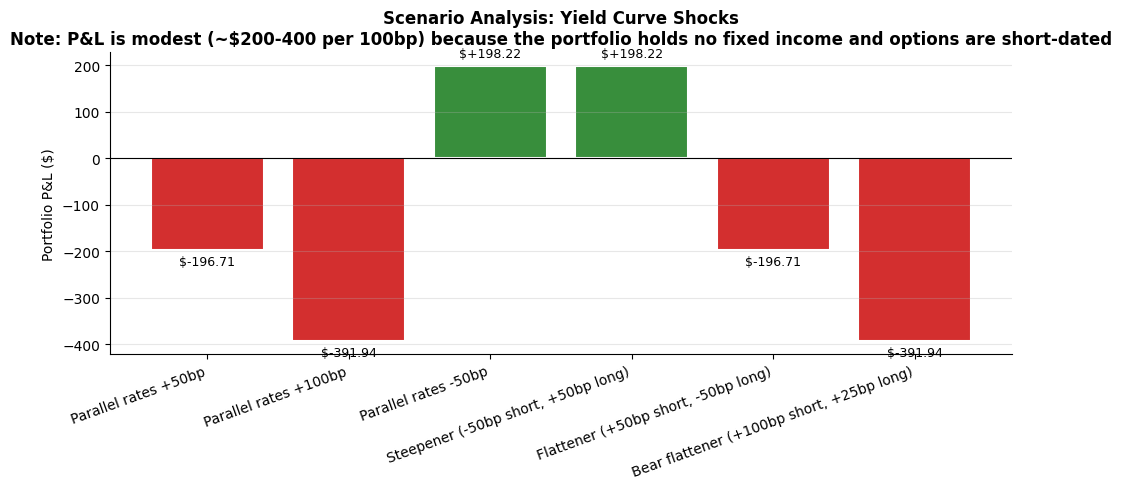

In [23]:
# Bar chart of P&L per yield curve scenario.
rate_labels = [r["Scenario"] for r in rate_rows if r["Scenario"] != "Base case"]
rate_pnls = [r["P&L ($)"] for r in rate_rows if r["Scenario"] != "Base case"]

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = ["#388E3C" if v >= 0 else "#D32F2F" for v in rate_pnls]
bars_r = ax.bar(range(len(rate_pnls)), rate_pnls, color=colors_r, edgecolor="white", linewidth=1.5)
ax.set_xticks(range(len(rate_pnls)))
ax.set_xticklabels(rate_labels, rotation=20, ha="right")
ax.set_ylabel("Portfolio P&L ($)")
ax.set_title("Scenario Analysis: Yield Curve Shocks\nNote: P&L is modest (~$200-400 per 100bp) because the portfolio holds no fixed income and options are short-dated",
             fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, v in zip(bars_r, rate_pnls):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + (max(np.abs(rate_pnls))*0.03 if v >= 0 else -max(np.abs(rate_pnls))*0.03),
            f"${v:+,.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
plt.tight_layout()
plt.show()

## 9.0 Limitations and Next Steps

The platform achieves its core goals — yield curve, four pricing methods (BS, Binomial European, Monte Carlo, Binomial American), three-way VaR with multi-asset correlated MC, correlation regime stress testing (Section 7.1), path-dependent portfolio MDD (Section 7.2), scenario stress across spot/vol/rates, position aggregation, and three distinct option strategies demonstrating hedging, income, and speculation use cases.

Three substantive limitations remain.

### Key limitations

**1. Sqrt-time scaling assumes i.i.d. returns.** Our 10-day VaR scales from 1-day estimates via √10. This assumes returns are independent and identically distributed across days. Real equity returns exhibit volatility clustering (high-vol days cluster) and modest negative autocorrelation, both violating i.i.d. The effect is to *underestimate* true multi-day VaR, particularly under stress.

**2. Static volatility assumption.** Black-Scholes assumes constant volatility through an option's life. Real volatility is time-varying, mean-reverting, and exhibits regime changes (the volatility smile is empirical evidence). Our static σ estimated from 2-year historical data is a useful approximation but understates option prices when implied vol is elevated. The vol-shock scenarios in Section 8.0 partially address this by stress-testing under elevated vol, but implementing a full implied vol surface would require ASX option chain data beyond the current scope.

**3. Constant option maturity in path-dependent MDD.** Our path-dependent portfolio MDD (Section 7.2) re-prices each option position with a constant time-to-maturity (T = 0.5) at every historical date. A more rigorous implementation would age options realistically and roll them at expiry, capturing option theta decay along the historical path. Our simplification approximates a "continuously rolled overlay" rather than a single static position.

**4. Trailing Dividend Yields as a proxy for forward yields.** The `div_yield` values sourced from yfinance represent the trailing 12-month dividend yield. Black-Scholes (Merton extension) requires the *expected* continuous dividend yield over the option's life, which is a forward-looking quantity. CBA and CSL have stable dividend payments, while BHP's dividends are highly variable and commodity-price sensitive. Therefore, the trailing yield can diverge significantly from the forward expectation. As a result, this can reduce the price of call options and inflate the price of put options. This will have a flow on effect to the dollar-delta and VaR estimates. A more rigorous implementation would be to integrate forward dividend estimates.
### Future work

- **Option ageing in MDD**: implement realistic time-to-maturity decay along historical paths, modelling option rolls every 6 months
- **Implied vol surface**: source ASX option chain data and back out implied vols per strike-maturity grid
- **Strategy backtesting**: extend the platform to compute realised P&L over a historical backtest window with transaction costs and option roll mechanics
- **Regime-switching covariance**: replace our two-state stress correlation analysis (Section 7.1) with a Markov-switching covariance estimator inferring regime transitions from data
- **American options for long-dated or high-dividend positions**: the platform's American pricing capability is demonstrated in Section 6.1 (cross-validation across all four portfolio positions) and in the derivatives exploration notebook. For our specific 6-month portfolio on low-to-medium-dividend stocks, the early-exercise premium is small (<1.2%) so we retain European pricing in the main analysis. A future portfolio with longer-dated positions or higher-dividend underlyings would benefit from native American treatment.